# Continual Learning with GAN Replay

This notebook first trains the conditional GAN, saves it to disk, and then runs the DFC continual-learning experiment with GAN replay.


In [1]:
# %load_ext autoreload
# %autoreload 2

import os
import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from networks.DFC_network import *
from src.dataloaders import *
from src.trainer_GAN import TrainerGAN, TrainerCL_DFC_GAN
from src.utils import *


/cluster/raid/home/sschwartz/.conda/envs/DFC_project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = {
    "layers": [784, 400, 10],
    "num_classes": 10,
    "lr": 1e-4,
    "lr_fb": 1e-4,
    "batch_size": 100,
    "batch_size_gen": 5000,
    "epochs": 20,
    "mode": "di",
    "num_workers": 0,
    "loss_fn": "ce",
    "optimizer": "Adam",
    "scheduler": "CosineAnnealingLR",
    "activation_fun": "Tanh",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "output_dir": "./outputs_cl_gan/",
    "seed": 1337,
    "taus": [0.02, 0.02, 0.02, 0.016, 0.01],
    "target_lr": 1,
    "alpha_di": 0.0017,
    "dt_di": 0.02,
    "time_constant_ratio": 0.2,
    "tmax_di": 2,
    "k_p": 2.0,
    "eps": 1e-4,
    "save": True,
    "flatten_imgs": "default",
    "num_tasks": 5,
    "classes_per_task": 2,
    "setting": "classIL5task",
    "first_task_only": False,
    "gan_result_root": "MNIST_cGAN_results",
    "gan_generator_path": "MNIST_cGAN_results/generator.pth",
    "gan_discriminator_path": "MNIST_cGAN_results/discriminator.pth",
    "gan_num_classes": 10,
    "gan_retrain_epochs": 100,
    "gan_latent_dim": 100,
    "gan_hidden_dim": 600,
    "gan_image_dim": 784,
    "gan_lr": 2e-4,
    "gan_epochs": 50,
    "data_mean": 0.1307,
    "data_std": 0.3081,
}

config = dotdict(config)



In [3]:
gan_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

gan_train_loader = DataLoader(
    datasets.MNIST("data", train=True, download=True, transform=gan_transform),
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
)

gan_train_loader


In [ ]:
gan_trainer = TrainerGAN(config, gan_train_loader)
gan_hist = gan_trainer.train()

print("Saved generator to:", config.gan_generator_path)
print("Saved discriminator to:", config.gan_discriminator_path)


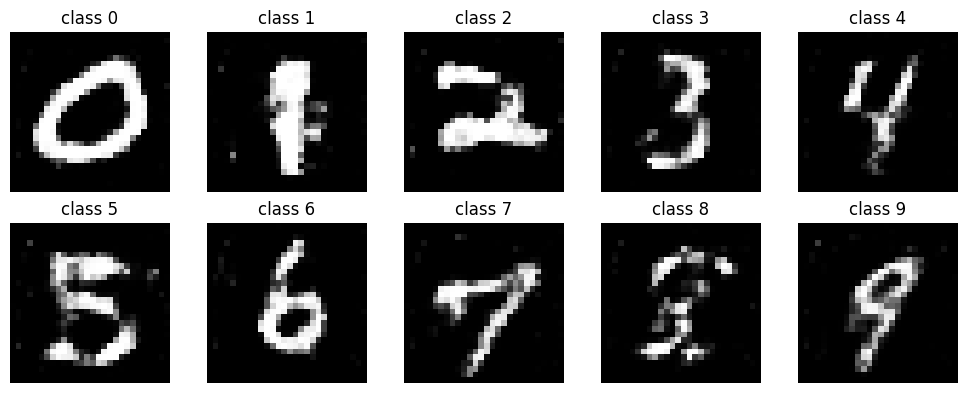

In [5]:
labels = torch.arange(10, device=gan_trainer.device)
gan_images = gan_trainer.generator.generate_from_labels(labels)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, img, label in zip(axes.flat, gan_images, labels.tolist()):
    ax.imshow(img.squeeze().detach().cpu(), cmap="gray", vmin=-1, vmax=1)
    ax.set_title(f"class {label}")
    ax.axis("off")
plt.tight_layout()


In [4]:
tasks_dataloaders = ClassILMNIST5Task(config=config).get_all_tasks_dataloaders()

model = DFCL_network_multilayer(config=config)
trainer = TrainerCL_DFC_GAN(model, tasks_dataloaders, config)

trainer.train()


[DFCL] Feedback connections initialized.
Training:
 - layers: [784, 400, 10]
 - num_classes: 10
 - lr: 0.0001
 - lr_fb: 0.0001
 - batch_size: 100
 - batch_size_gen: 5000
 - epochs: 20
 - mode: di
 - num_workers: 0
 - loss_fn: ce
 - optimizer: Adam
 - scheduler: CosineAnnealingLR
 - activation_fun: Tanh
 - device: cuda
 - output_dir: ./outputs_cl_gan/
 - seed: 1337
 - taus: [0.02, 0.02, 0.02, 0.016, 0.01]
 - target_lr: 1
 - alpha_di: 0.0017
 - dt_di: 0.02
 - time_constant_ratio: 0.2
 - tmax_di: 2
 - k_p: 2.0
 - eps: 0.0001
 - save: True
 - flatten_imgs: default
 - num_tasks: 5
 - classes_per_task: 2
 - setting: classIL5task
 - first_task_only: False
 - gan_result_root: MNIST_cGAN_results
 - gan_generator_path: MNIST_cGAN_results/generator.pth
 - gan_discriminator_path: MNIST_cGAN_results/discriminator.pth
 - gan_num_classes: 10
 - gan_retrain_epochs: 100
 - gan_latent_dim: 100
 - gan_hidden_dim: 600
 - gan_image_dim: 784
 - gan_lr: 0.0002
 - gan_epochs: 50
 - data_mean: 0.1307
 - data_s

				Epoch: 001, Train loss: 1.4267 & test losses: T0: 0.2091 & accuracy: T0: 99.39, Full: 99.39


				Epoch: 002, Train loss: 0.1060 & test losses: T0: 0.0514 & accuracy: T0: 99.67, Full: 99.67


				Epoch: 003, Train loss: 0.0395 & test losses: T0: 0.0251 & accuracy: T0: 99.86, Full: 99.86


				Epoch: 004, Train loss: 0.0227 & test losses: T0: 0.0157 & accuracy: T0: 99.86, Full: 99.86


...

				Epoch: 019, Train loss: 0.4119 & test losses: T0: 6.1982, T1: 7.6272, T2: 9.2743, T3: 5.9771, T4: 0.0295 & accuracy: T0: 0.66, T1: 0.10, T2: 0.00, T3: 0.70, T4: 98.79, Full: 19.89


				Epoch: 020, Train loss: 0.4117 & test losses: T0: 6.3097, T1: 7.7337, T2: 9.3853, T3: 6.0530, T4: 0.0287 & accuracy: T0: 0.47, T1: 0.10, T2: 0.00, T3: 0.60, T4: 98.79, Full: 19.83
Training a new GAN after task 5 for 100 epochs
GAN training start!
[1/100] D: 0.688, G: 1.418
[2/100] D: 0.398, G: 2.061
[3/100] D: 0.240, G: 2.593
[4/100] D: 0.157, G: 3.038
[5/100] D: 0.071, G: 3.523
[6/100] D: 0.039, G: 4.148
[7/100] D: 0.027, G: 4.571
[8/100] D: 0.140, G: 3.872
[9/100] D: 0.107, G: 3.767
[10/100] D: 0.080, G: 4.165
[11/100] D: 0.058, G: 4.627
[12/100] D: 0.026, G: 4.871
[13/100] D: 0.014, G: 5.269
[14/100] D: 0.009, G: 5.653
[15/100] D: 0.007, G: 6.023
[16/100] D: 0.006, G: 6.139
[17/100] D: 0.152, G: 4.219
[18/100] D: 0.054, G: 4.725
[19/100] D: 0.050, G: 4.737
[20/100] D: 0.050, G: 5.159
[21/100] D: 0.033, G: 5.150
[22/100] D: 0.021, G: 5.524
[23/100] D: 0.026, G: 5.777
[24/100] D: 0.056, G: 5.434
[25/100] D: 0.020, G: 5.440
[26/100] D: 0.022, G: 5.768
[27/100] D: 0.032, G: 5.890
[2

Testing  epoch 000/20:  66%|██████▌   | 66/100 [00:00<00:00, 655.04batch/s]

Seen Classes - Loss: 5.8803, Accuracy: 19.8300


Testing  epoch 000/20: 100%|██████████| 100/100 [00:11<00:00, 655.04batch/s]

In [ ]:

plot_generated_inputs(trainer.gen_samples[0][:100], n_cols=10, title="Generated Samples after Task 4", save=False, filename="Samples_BP_100_epochs.png")

In [6]:
trainer.gen_samples[0][:20].min()

tensor(-0.4242, device='cuda:0')

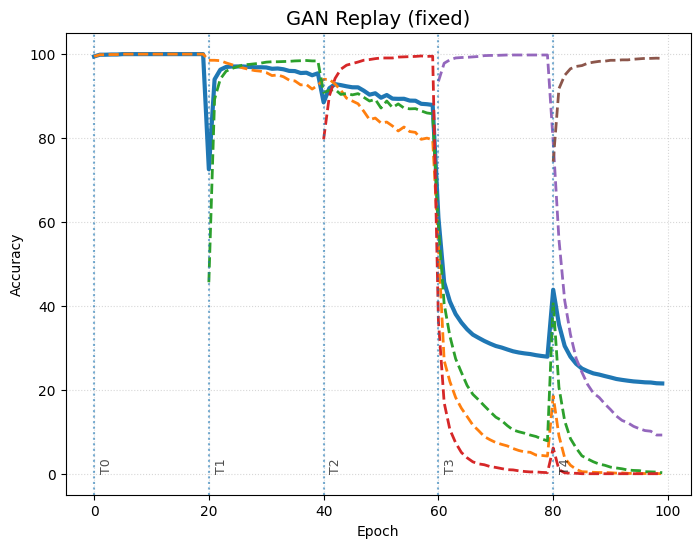

In [4]:
plt.figure(figsize=(10, 6))

# ... your plotting code ...

# Plot full accuracy
plt.plot(
    trainer.accuracies_full,
    label="Overall Accuracy",
    linewidth=3
)

# Plot task accuracies
for i, acc in enumerate(trainer.accuracies_tasks):
    epochs = range(i * 20, i * 20 + len(acc))
    plt.plot(
        epochs,
        acc,
        linestyle="--",
        linewidth=2,
        label=f"Task {i}"
    )

# --- Mark task boundaries ---
num_tasks = len(trainer.accuracies_tasks)
for i in range(num_tasks):
    x = i * 20
    plt.axvline(
        x=x,
        linestyle=":",
        alpha=0.6,
        linewidth=1.5
    )
    plt.text(
        x + 1,
        0.02,  # adjust depending on your y-range
        f"T{i}",
        rotation=90,
        verticalalignment='bottom',
        fontsize=9,
        alpha=0.7
    )

# Labels and styling
plt.title("GAN Replay (fixed)", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim([-5,105])

plt.grid(True, linestyle=":", alpha=0.5)

"""plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)"""

# Reserve space on the right for legend
plt.subplots_adjust(right=0.75)


#plt.tight_layout()
plt.show()

In [ ]:
labels = torch.arange(10, device=trainer.device)
gan_images = trainer.gan.generate_from_labels(labels)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, img, label in zip(axes.flat, gan_images, labels.tolist()):
    ax.imshow(img.squeeze().detach().cpu(), cmap="gray", vmin=-1, vmax=1)
    ax.set_title(f"class {label}")
    ax.axis("off")
plt.tight_layout()


In [9]:
if len(trainer.gen_datasets) > 0:
    replay_x, replay_y = trainer.gen_datasets[0][:16]
    replay_labels = replay_y.argmax(dim=1)

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for ax, img, label in zip(axes.flat, replay_x, replay_labels.tolist()):
        ax.imshow(img.view(28, 28), cmap="gray")
        ax.set_title(f"pred {label}")
        ax.axis("off")
    plt.tight_layout()
else:
    print("Replay dataset is empty. Run training through at least task 2 to populate it.")


tensor(1.0000, device='cuda:0')


In [3]:
# Train a standalone GAN on the full MNIST dataset
full_gan_config = dotdict(dict(config))
full_gan_config.gan_result_root = "MNIST_cGAN_results_full"
full_gan_config.gan_generator_path = os.path.join(full_gan_config.gan_result_root, "generator.pth")
full_gan_config.gan_discriminator_path = os.path.join(full_gan_config.gan_result_root, "discriminator.pth")

full_gan_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

full_gan_loader = DataLoader(
    datasets.MNIST("data", train=True, download=True, transform=full_gan_transform),
    batch_size=full_gan_config.batch_size,
    shuffle=True,
    num_workers=full_gan_config.num_workers,
)

full_gan_trainer = TrainerGAN(full_gan_config, full_gan_loader)
full_gan_hist = full_gan_trainer.train()

print("Saved full-MNIST generator to:", full_gan_config.gan_generator_path)
print("Saved full-MNIST discriminator to:", full_gan_config.gan_discriminator_path)


GAN training start!
[1/50] D: 0.940, G: 1.239
[2/50] D: 0.784, G: 1.638
[3/50] D: 0.768, G: 1.735
[4/50] D: 0.793, G: 1.768
[5/50] D: 0.784, G: 1.774
[6/50] D: 0.736, G: 1.929
[7/50] D: 0.714, G: 1.998
[8/50] D: 0.772, G: 1.887
[9/50] D: 0.773, G: 1.854
[10/50] D: 0.778, G: 1.842
[11/50] D: 0.806, G: 1.752
[12/50] D: 0.839, G: 1.689
[13/50] D: 0.866, G: 1.652
[14/50] D: 0.865, G: 1.630
[15/50] D: 0.846, G: 1.678
[16/50] D: 0.815, G: 1.727
[17/50] D: 0.785, G: 1.790
[18/50] D: 0.668, G: 1.974
[19/50] D: 0.666, G: 2.063
[20/50] D: 0.548, G: 2.325
[21/50] D: 0.512, G: 2.452
[22/50] D: 0.588, G: 2.202
[23/50] D: 0.432, G: 2.643
[24/50] D: 0.539, G: 2.369
[25/50] D: 0.539, G: 2.344
[26/50] D: 0.500, G: 2.483
[27/50] D: 0.494, G: 2.518
[28/50] D: 0.458, G: 2.621
[29/50] D: 0.447, G: 2.709
[30/50] D: 0.455, G: 2.651
[31/50] D: 0.440, G: 2.673
[32/50] D: 0.459, G: 2.718
[33/50] D: 0.411, G: 2.800
[34/50] D: 0.385, G: 2.835
[35/50] D: 0.303, G: 3.177
[36/50] D: 0.325, G: 3.225
[37/50] D: 0.407,

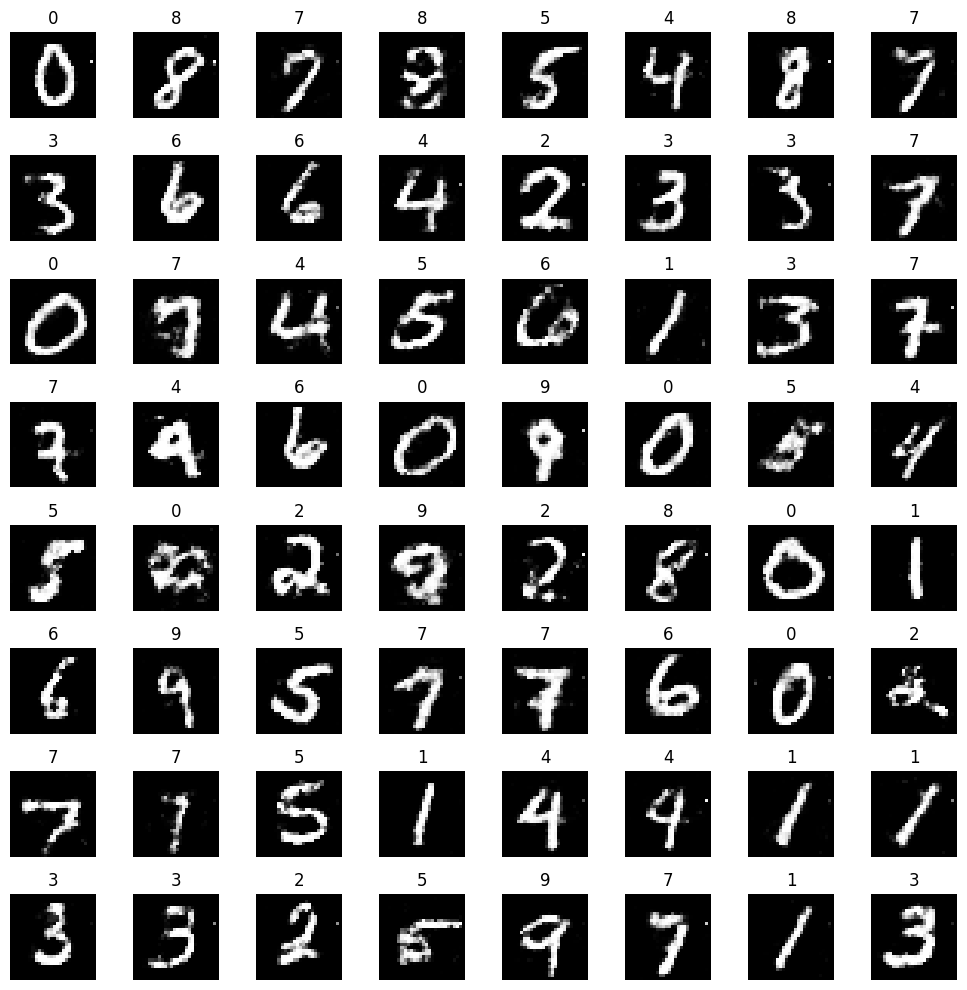

In [4]:

# Generate a bunch of random GAN images

n_images = 64
n_cols = 8
n_rows = n_images // n_cols

# choose which GAN you want to use
G = full_gan_trainer.generator  # or trainer.gan

# random class labels
random_labels = torch.randint(
    low=0,
    high=G.num_classes,
    size=(n_images,),
    device=next(G.parameters()).device,
)

with torch.no_grad():
    random_images = G.generate_from_labels(random_labels)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10))
for ax, img, label in zip(axes.flat, random_images, random_labels.tolist()):
    ax.imshow(img.squeeze().cpu(), cmap="gray", vmin=-1, vmax=1)
    ax.set_title(str(label))
    ax.axis("off")

plt.tight_layout()
